# Inspect processed CASIA2

Sanity-check `data/processed/casia2/` after running `utils/prepare_casia2.py`.

In [3]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "ipynb":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data import CASIA2Dataset

PROCESSED = ROOT / "data" / "processed" / "casia2"
print(PROCESSED)

/home/bonavina/Documentos/Github/mt-unet/data/processed/casia2


In [4]:
summary = json.loads((PROCESSED / "summary.json").read_text())
print(json.dumps({k: summary[k] for k in ("size", "seed", "n_authentic", "n_tampered", "n_paired_tampered", "n_exact", "n_gt3", "n_id_fallback", "splits") if k in summary}, indent=2))
print("unpaired images", summary.get("unpaired_images"))
print("unpaired masks", summary.get("unpaired_masks"))

{
  "size": 256,
  "seed": 42,
  "n_authentic": 7491,
  "n_tampered": 5123,
  "n_paired_tampered": 5123,
  "n_exact": 4981,
  "n_gt3": 1,
  "n_id_fallback": 141,
  "splits": {
    "train": {
      "n": 8829,
      "authentic": 5243,
      "tampered": 3586,
      "tamper_D": 1272,
      "tamper_S": 2314
    },
    "val": {
      "n": 1892,
      "authentic": 1124,
      "tampered": 768,
      "tamper_D": 296,
      "tamper_S": 472
    },
    "test": {
      "n": 1893,
      "authentic": 1124,
      "tampered": 769,
      "tamper_D": 281,
      "tamper_S": 488
    }
  }
}
unpaired images []
unpaired masks []


In [5]:
frames = {split: pd.read_csv(PROCESSED / f"{split}.csv") for split in ("train", "val", "test")}
counts = pd.concat(
    {split: frame.groupby("label").size().rename({0: "authentic", 1: "tampered"}) for split, frame in frames.items()},
    axis=1,
)
counts

,train,val,test
label,,,
authentic,5243,1124,1124
tampered,3586,768,769


In [6]:
def overlay(image: Image.Image, mask: Image.Image, color=(255, 0, 0), alpha=0.45) -> Image.Image:
    rgb = image.convert("RGB")
    binary = np.asarray(mask.convert("L")) > 127
    tint = Image.new("RGB", rgb.size, color)
    blended = Image.blend(rgb, tint, alpha)
    out = rgb.copy()
    out.paste(blended, mask=Image.fromarray((binary * 255).astype("uint8"), mode="L"))
    return out


def show_row(row: pd.Series, title: str) -> None:
    image = Image.open(PROCESSED / row["image_path"])
    mask = Image.open(PROCESSED / row["mask_path"])
    print(title, row["stem"], "label", int(row["label"]), image.size, mask.size, mask.mode)
    display(overlay(image, mask) if int(row["label"]) == 1 else image)
    display(ImageOps.autocontrast(mask.convert("L")))

authentic Au_ani_00001 label 0 (256, 256) (256, 256) L


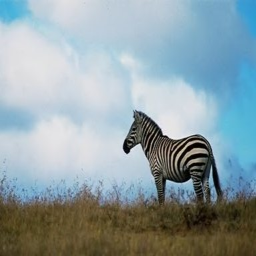

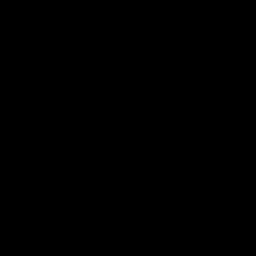

tampered Tp_D_CND_M_N_ani00018_sec00096_00138 label 1 (256, 256) (256, 256) L


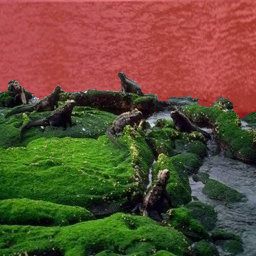

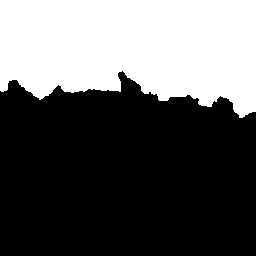

In [7]:
train = frames["train"]
auth = train[train["label"] == 0].iloc[0]
tamp = train[train["label"] == 1].iloc[0]
show_row(auth, "authentic")
show_row(tamp, "tampered")

In [8]:
ds = CASIA2Dataset(PROCESSED, split="val")
item = ds[0]
print(item["stem"], tuple(item["image"].shape), tuple(item["mask"].shape), item["label"].item())
assert item["image"].shape == (3, 256, 256)
assert item["mask"].shape == (1, 256, 256)
print("val size", len(ds))

Au_ani_00003 (3, 256, 256) (1, 256, 256) 0
val size 1892


In [9]:
bad_size = []
for split, frame in frames.items():
    for row in frame.sample(n=min(12, len(frame)), random_state=0).itertuples():
        image = Image.open(PROCESSED / row.image_path)
        mask = Image.open(PROCESSED / row.mask_path)
        if image.size != (256, 256) or mask.size != (256, 256):
            bad_size.append((split, row.stem, image.size, mask.size))
print("size mismatches in sample", bad_size)

size mismatches in sample []
